# **Hierarchical Clustering**


Hierarchical Clustering is an unsupervised learning algorithm that builds a hierarchy of clusters. Unlike K-Means, which tries to find a flat partition, this algorithm creates a "tree" of clusters.


### **1. How it works: The "Bottom-Up" Strategy**
1.  **Starts with N Clusters:** Every single data point starts as its own individual cluster.
2.  **Merging Phase:** Find the two closest data points (or clusters) and merge them into one. 
3.  **Repeat:** Keep merging the closest clusters until only one giant cluster (containing everything) remains.

### **2. The Dendrogram (The "Family Tree")**
This is the most powerful part of Hierarchical Clustering. A **Dendrogram** is a visualization that shows exactly which points were merged and in what order.
*   **Vertical axis:** Represents the distance (dissimilarity) between clusters.
*   **Horizontal axis:** Represents the individual data points.
*   **Choosing K:** You can decide how many clusters you want *after* the algorithm is done by "cutting" the tree at a certain height.


### **3. Hierarchical vs. K-Means: Why choose this one?**

| Feature | K-Means | Hierarchical Clustering |
| :--- | :--- | :--- |
| **Number of Clusters** | Must specify `k` **before** training. | You can choose `k` **after** seeing the tree. |
| **Cluster Shape** | Expects spherical clusters. | Can handle more complex shapes. |
| **Stability** | Depends on random initialization (Centroids). | **Deterministic** (gives the same result every time). |
| **Speed** | ⚡ Very Fast (Good for millions of rows). | 🐢 Slow (Hard to run on massive datasets). |
| **Visual Insight** | Gives you a simple group label. | Gives you a "Dendrogram" showing relationships. |


### **4. When to use Hierarchical over K-Means?**

1.  **When you don't know K:** If you have no idea how many groups exist, the Dendrogram helps you "see" the natural breaks in the data.
2.  **When taxonomy matters:** If you want to see sub-groups (e.g., "These people are in the *Sports* cluster, and within that, these are specifically *Cricket fans*").
3.  **When results must be consistent:** K-Means might give different labels if you run it twice. Hierarchical will always give the exact same tree for the same data.
4.  **Handling Noise:** Hierarchical clustering (especially with *Single Linkage*) can sometimes identify outliers more effectively than K-Means.


### **Common Linkage Methods (How we measure "Closeness")**
*   **Ward:** Minimizes the variance within clusters (Default and most popular).
*   **Complete:** Uses the maximum distance between points in two clusters.
*   **Average:** Uses the average distance between all points in two clusters.
*   **Single:** Uses the minimum distance (can create "chain-like" long clusters).


This is how KMeans fails on the difficult clusters...
Bcoz it works on distance to centroid mechanism.


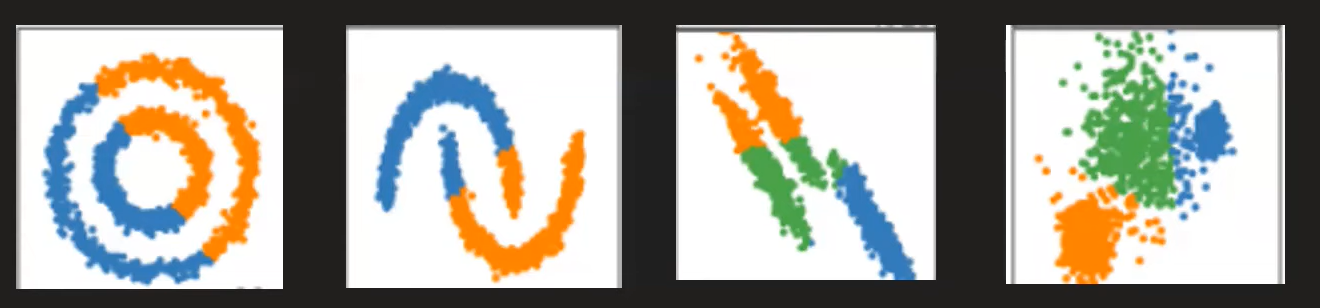

There are two types clustering

1. Agglomerative clustering
2. Divisive clustering


Hierarchical clustering is divided into two main strategies based on whether you start by merging small pieces or by splitting a giant whole.


### **1. Agglomerative Clustering (Bottom-Up)**
This is the most common approach (the one used by Scikit-Learn's `AgglomerativeClustering`).
*   **Concept:** It starts with everyone being alone and slowly builds "friendship groups."
*   **Working (Step-by-Step):**
    1.  **Initial State:** Every data point is treated as a **separate cluster** (If you have 100 points, you start with 100 clusters).
    2.  **Calculate Proximity:** The algorithm calculates the distance between all clusters using a **proximity matrix**.
    3.  **Merge:** It finds the two "closest" clusters and merges them into a single cluster.
    4.  **Update Matrix:** The distance between the newly formed cluster and all remaining clusters is recalculated.
    5.  **Repeat:** Steps 3 and 4 are repeated until only **one giant cluster** remains.
*   **Analogy:** Building a family tree from individuals $\rightarrow$ siblings $\rightarrow$ parents $\rightarrow$ ancestors.

Link -- https://youtu.be/Ka5i9TVUT-E?si=H0hpypZUgTt3N5uk&t=461

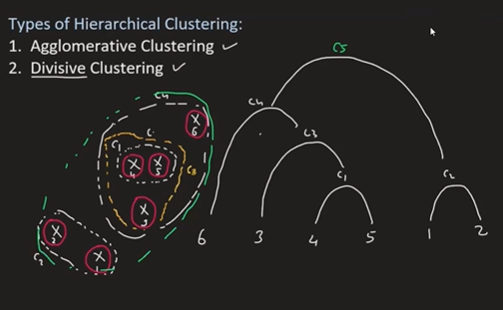

This tree like structure in the img is called Dendogram.

How to choose the required clusters
- remove the c5 circle and you will be left with 2 clusters
- remove the c4 circle and you will be left with 3 clusters
- remove the c3 circle and you will be left with 4 clusters
- remove the c2 circle and you will be left with 5 clusters
- remove the c1 circle and you will be left with 6 clusters

The clusters are keep getting increasing as you keep removing the upper clusters (such as c3, c4, c5), this is bcoz every point in itself is a cluster. This is called Agglomerative clustering.

But Divisive clustering works the exact opposite of Agglomerative clustering. At the very first stage, it combines all data points into one big single cluster. Then, it divides that giant cluster into two smaller clusters by identifying the points that are most different (dissimilar) from each other.The algorithm then recursively picks a cluster (usually the one with the most internal variation) and splits it again. This process repeats until a stopping point is reached or until every individual data point becomes its own separate cluster.



### **2. Divisive Clustering (Top-Down)**
This is much rarer and more computationally expensive. There isn't a direct implementation in standard Scikit-Learn, though it can be built.
*   **Concept:** It starts with everyone in one room and slowly kicks people out into separate groups.
*   **Working (Step-by-Step):**
    1.  **Initial State:** All data points start in **one single cluster** (The root).
    2.  **Calculate Dissimilarity:** The algorithm identifies which points are the "most different" from the rest of the group.
    3.  **Split:** The giant cluster is split into two smaller, more homogeneous clusters.
    4.  **Choose Next:** It looks at the existing clusters and picks the one with the highest "internal disagreement" (variance) to split again.
    5.  **Repeat:** This continues until **every point is its own cluster**.
*   **Analogy:** A large corporation splitting into departments $\rightarrow$ teams $\rightarrow$ individual roles.


### **Key Comparison: Why Agglomerative is more popular?**
| Feature | Agglomerative (Bottom-Up) | Divisive (Top-Down) |
| :--- | :--- | :--- |
| **Logic** | **Merging:** Small to Big. | **Splitting:** Big to Small. |
| **Complexity** | $O(N^2 \log N)$ - Manageable. | $O(2^N)$ - **Extremely Heavy**. |
| **Availability** | Available in almost all ML libraries. | Rare (Hard to find "optimal" splits). |
| **Focus** | Good at identifying **small, tight clusters**. | Better at identifying the **global structure**. |
| **Decision Style** | Greedy (Local decisions). | Global (Looks at the whole set before splitting). |


### **Which one to choose?**
*   **Agglomerative** is the industry standard. It is efficient and works perfectly for 99% of clustering tasks.
*   **Divisive** is only used when the "Overall Structure" of the data is more important than the individual points, or when you only need to make a few top-level splits in a very specific hierarchy.
### **Working Mechanism: The Core Logic**
To make either strategy work, the algorithm depends on two things:
1.  **Distance Metric:** How do we measure distance between points? (*Euclidean, Manhattan, etc.*)
2.  **Linkage Criteria:** How do we measure distance between **groups**? (*Ward, Complete, Single, Average*). 
    *   *Example:* In Agglomerative, Ward's method is usually selected because it creates the most "even" and balanced clusters.


There are 4 types of Agglomerative Clustering

1. Min (single link)
    - The distance between two clusters is defined as the minimum distance between any single data point in the first cluster and any single data point in the second cluster.
    - Bascially this is the shortest distance btwn any two points of two different clusters.
    - not good with outliers
2. Max (completer link)
    - The distance between two clusters is defined as the maximum distance between any single data point in the first cluster and any single data point in the second cluster.
    - Basically this is the longest distance between any two points of two different clusters.
    - good with the outliers
    - not good with two or more segregated clusters
3. Average
    - This is the perfect mix of min and max
    - The distance between two clusters is defined as the average distance between each point in one cluster to every point in the other cluster.
    - Basically this is the average distance between all pairs of points from two different clusters.
    - less sensitive to outliers.
4. Ward
    - This is the default value in sklearn
    - The distance between two clusters is defined by the increase in the sum of squared errors (SSE) when they are merged.
    - Basically, it minimizes the total within-cluster variance.
    - It is the most popular method as it tends to create clusters of relatively equal size and is robust to noise.
    - Helps reducing the variance